In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sample_df = pd.read_csv("TMBD Movie Dataset.csv")
sample_df

,Unnamed: 0,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,...,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj,profit,popularity_level
0,0,135397,tt0369610,32.985763,150000000.0,1.513529e+09,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,...,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,2015-06-09,5562,6.5,2015,1.379999e+08,1.392446e+09,1.363529e+09,High
1,1,76341,tt1392190,28.419936,150000000.0,3.784364e+08,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,...,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,2015-05-13,6185,7.1,2015,1.379999e+08,3.481613e+08,2.284364e+08,High
2,2,262500,tt2908446,13.112507,110000000.0,2.952382e+08,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,...,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,2015-03-18,2480,6.3,2015,1.012000e+08,2.716190e+08,1.852382e+08,High
3,3,140607,tt2488496,11.173104,200000000.0,2.068178e+09,Star Wars: The Force Awakens,Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,http://www.starwars.com/films/star-wars-episod...,J.J. Abrams,...,Action|Adventure|Science Fiction|Fantasy,Lucasfilm|Truenorth Productions|Bad Robot,2015-12-15,5292,7.5,2015,1.839999e+08,1.902723e+09,1.868178e+09,High
4,4,168259,tt2820852,9.335014,190000000.0,1.506249e+09,Furious 7,Vin Diesel|Paul Walker|Jason Statham|Michelle ...,http://www.furious7.com/,James Wan,...,Action|Crime|Thriller,Universal Pictures|Original Film|Media Rights ...,2015-04-01,2947,7.3,2015,1.747999e+08,1.385749e+09,1.316249e+09,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1282,10595,253,tt0070328,1.549139,7000000.0,1.617778e+08,Live and Let Die,Roger Moore|Yaphet Kotto|Jane Seymour|Clifton ...,http://www.mgm.com/view/movie/1130/Live-and-Le...,Guy Hamilton,...,Adventure|Action|Thriller,Eon Productions|Metro-Goldwyn-Mayer (MGM),1973-07-05,293,6.1,1973,3.437812e+07,7.945168e+08,1.547778e+08,Moderately High
1283,10689,660,tt0059800,1.910465,11000000.0,1.411957e+08,Thunderball,Sean Connery|Claudine Auger|Adolfo Celi|Lucian...,http://www.mgm.com/view/movie/2009/Thunderball/,Terence Young,...,Adventure|Action|Thriller,Eon Productions|Metro-Goldwyn-Mayer (MGM),2065-12-16,331,6.3,1965,7.612620e+07,9.771535e+08,1.301957e+08,Moderately High
1284,10724,668,tt0064757,1.778746,7000000.0,8.197449e+07,On Her Majesty's Secret Service,George Lazenby|Diana Rigg|Telly Savalas|Gabrie...,http://www.mgm.com/view/movie/1411/On-Her-Maje...,Peter R. Hunt,...,Adventure|Action|Thriller,Eon Productions|Metro-Goldwyn-Mayer (MGM)|Danjaq,2069-12-12,258,6.4,1969,4.160985e+07,4.872780e+08,7.497449e+07,Moderately High
1285,10759,948,tt0077651,1.198849,300000.0,7.000000e+07,Halloween,Donald Pleasence|Jamie Lee Curtis|P.J. Soles|N...,http://www.theofficialjohncarpenter.com/hallow...,John Carpenter,...,Horror|Thriller,Compass International Pictures|Falcon Internat...,1978-10-25,522,7.3,1978,1.002810e+06,2.339890e+08,6.970000e+07,Moderately High


In [ ]:
sample_df = pd.read_csv("TMBD Movie Dataset.csv")
sample_df["Return on Investment"] = (sample_df['revenue'] / sample_df['budget'])
sample_df["ROI"] = sample_df["Return on Investment"].apply(lambda x: 1 if x > 2.75 else 0)
dummies = sample_df['genres'].str.get_dummies(sep = "|")
sample_df = sample_df.join(dummies)
sample_df = sample_df.drop(columns = ["genres"])
sample_df.to_csv("NewROI.csv")
#creates two new columns, ROI and Return on Investment, one-hot encoding on genres to split

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("NewROI.csv")
train_df, test_df = train_test_split(df, test_size = 0.2, random_state = 42)
train_df.to_csv("train.csv")
test_df.to_csv("test.csv")

train_sample = pd.read_csv("train.csv")
test_sample = pd.read_csv("test.csv")
#splits dataset into 80% train and 20% test

In [ ]:
import pandas as pd

sample_df = pd.read_csv("train.csv")
sample_specific = sample_df["ROI"]
sample_features = sample_df[['popularity', 'runtime', 'vote_average', 'budget', 'Action',	'Adventure',	'Animation',	'Comedy',	'Crime',	'Documentary',	'Drama',	'Family',	'Fantasy',	'Foreign',	'History',	'Horror',	'Music',	'Mystery',	'Romance',	'Science Fiction',	'Thriller',	'War',	'Western']]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

lr_classifier = LogisticRegression(solver = 'lbfgs', max_iter = 10000, class_weight = 'balanced')
mlp_classifier = MLPClassifier(solver = 'lbfgs', alpha = 1e-5, hidden_layer_sizes = (8, 2), random_state = 11, max_iter = 10000)

lr_classifier.fit(sample_features.to_numpy(), sample_specific.to_numpy())
mlp_classifier.fit(sample_features.to_numpy(), sample_specific.to_numpy())

#prompts and trains model

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=2):
ABNORMAL: .

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


MLPClassifier(alpha=1e-05, hidden_layer_sizes=(8, 2), max_iter=10000,
              random_state=11, solver='lbfgs')

In [ ]:
from sklearn.metrics import accuracy_score

new_df = pd.read_csv('test.csv')

new_inputs = new_df[['popularity', 'runtime', 'vote_average', 'budget', 'Action',	'Adventure',	'Animation',	'Comedy',	'Crime',	'Documentary',	'Drama',	'Family',	'Fantasy',	'Foreign',	'History',	'Horror',	'Music',	'Mystery',	'Romance',	'Science Fiction',	'Thriller',	'War',	'Western']]
new_actual = new_df['ROI']

predicted_lr = lr_classifier.predict(new_inputs.to_numpy())
lr_accuracy_score = accuracy_score(predicted_lr, new_actual)

predicted_mlp = mlp_classifier.predict(new_inputs.to_numpy())
mlp_accuracy_score = accuracy_score(predicted_mlp, new_actual)

print (lr_accuracy_score)
print(mlp_accuracy_score)

#finding accuracy for metrics relative to ROI

0.4844961240310077
0.5426356589147286


In [ ]:
from sklearn.metrics import classification_report
print(classification_report(new_actual, predicted_lr))
#classification report for our model

              precision    recall  f1-score   support

           0       0.53      0.52      0.52       140
           1       0.44      0.44      0.44       118

    accuracy                           0.48       258
   macro avg       0.48      0.48      0.48       258
weighted avg       0.48      0.48      0.48       258



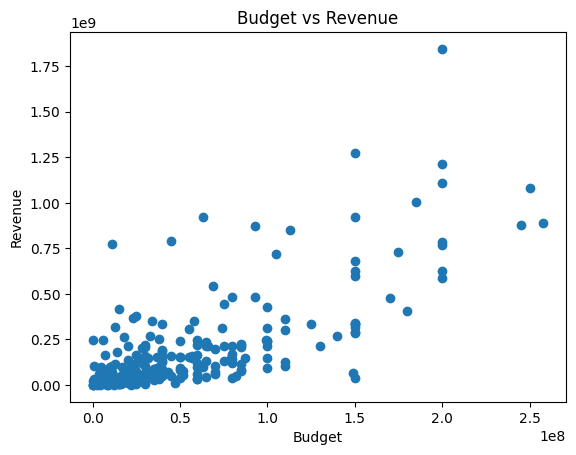

In [ ]:
plt.figure()
plt.scatter(new_df['budget'],new_df['revenue'])
plt.xlabel("Budget")
plt.ylabel("Revenue")
plt.title("Budget vs Revenue")
plt.show()

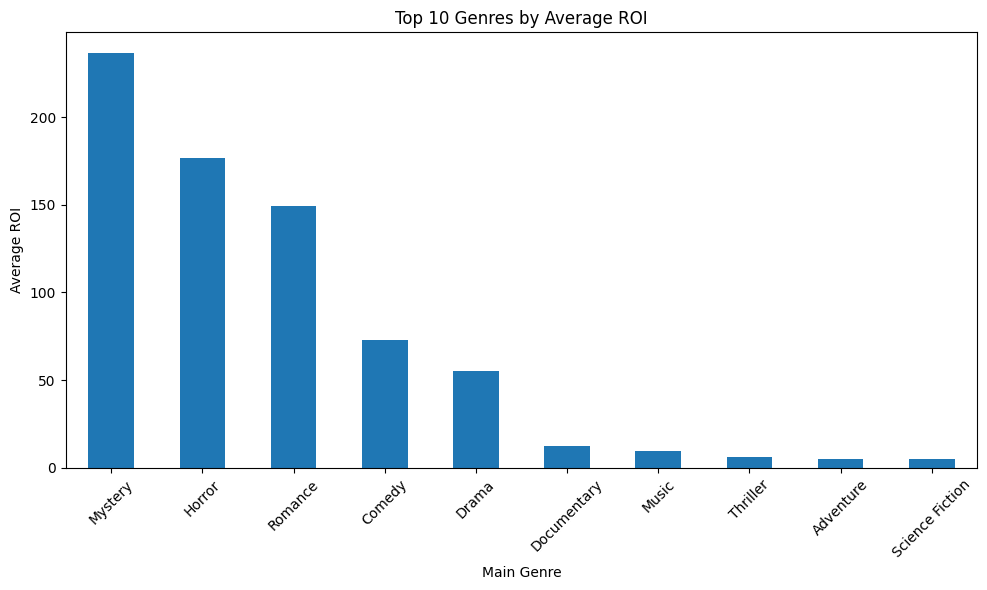

In [ ]:
genre_columns = ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War', 'Western']
genre_roi = pd.Series(dtype=float)
for genre in genre_columns:
    genre_roi[genre] = df[df[genre] == 1]['Return on Investment'].mean()

# Filter for top 10 genres by average ROI
genre_roi = genre_roi.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
genre_roi.plot(kind="bar")
plt.xlabel("Main Genre")
plt.ylabel("Average ROI")
plt.title("Top 10 Genres by Average ROI")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['release_year'], bins=30)
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movies by Release Year")
plt.tight_layout()
plt.show()

NameError: name 'plt' is not defined